### The Simplest Idea in ML

Imagine you just moved to a new city — let's say Tokyo. You're hungry, you don't speak the language, and Google Maps is down. What do you do? You look around. Three ramen shops nearby are packed with locals. One fancy place across town has a 5-star rating online. You go with the ramen — your *nearest neighbors* already made the decision for you.

**That's KNN.** To classify a new data point, look at its *k* nearest neighbors in the training data and take a majority vote.

No training phase. No model to fit. No assumptions about the data. Just store everything and compute distances when you need a prediction. It's the algorithm equivalent of "when in Rome, do as the Romans do."

### The Algorithm (4 Steps)

1. Pick a value of *k* (e.g. 3, 5, 7)
2. Compute the distance from the query point to **every** training point
3. Find the *k* closest ones
4. Return the majority class among those *k* neighbors

### Building KNN from Scratch

Let's build it step by step — like assembling IKEA furniture, but with fewer leftover screws. First, we need a way to measure distance between two points — the **Euclidean distance** (straight-line distance from geometry class):

In [ ]:
import numpy as np

def dist(x, y, axis=0):
    if not isinstance(x, np.ndarray): x, y = np.array(x), np.array(y)
    return np.sqrt(((x - y) ** 2).sum(axis=axis, keepdims=True))

dist([1,1],[1,1]), dist([1,1],[1,2])

(array([0.]), array([1.]))

Now the KNN classifier itself — compute distances, find the *k* nearest, take a majority vote:

In [ ]:
X_train = np.array([[1,2],[2,3],[3,3],[6,7],[7,8],[8,7]])
y_train = np.array([0, 0, 0, 1, 1, 1])  # two clusters: class 0 and class 1
x_query = np.array([2.5, 3.0])
k = 3

def knn_predict(X_train, y_train, x_query, k):
    """Classify x_query using k nearest neighbors."""
    dists = dist(x_query, X_train, axis=1).squeeze()
    top_k = dists.argsort()[:k]
    labels = y_train[top_k]
    return np.bincount(labels).argmax()

knn_predict(X_train, y_train, x_query, k=3)

np.int64(0)

**Result:** Class `0` ✅ — makes sense, since `[2.5, 3.0]` is geometrically close to the class 0 cluster.

**Caveat:** `np.bincount` requires non-negative integer labels (0, 1, 2, ...). For arbitrary labels, use `collections.Counter` for the majority vote instead.

### Seeing KNN in Action

Words are nice, but a picture is worth a thousand distances. Let's plot the two clusters, a query point sitting between them, and draw lines to its *k* nearest neighbors:

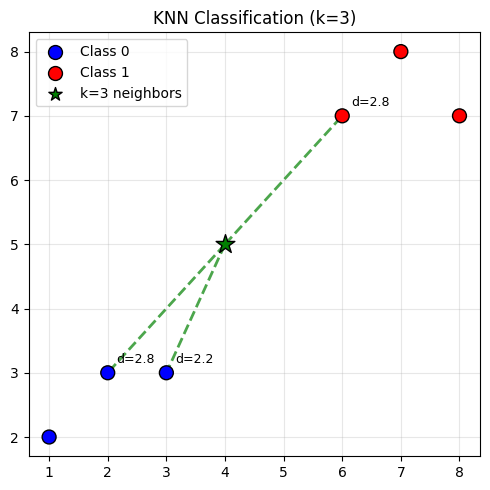

In [ ]:
#| code-fold: True
import matplotlib.pyplot as plt

X_train = np.array([[1,2],[2,3],[3,3],[6,7],[7,8],[8,7]])
y_train = np.array([0, 0, 0, 1, 1, 1])
x_query = np.array([4, 5])
k = 3

dists = np.sqrt(((X_train - x_query)**2).sum(axis=1))
top_k = dists.argsort()[:k]

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['blue' if c == 0 else 'red' for c in y_train]
ax.scatter(X_train[:,0], X_train[:,1], c=colors, s=100, edgecolors='k', zorder=3)

for i in top_k:
    ax.plot([x_query[0], X_train[i,0]], [x_query[1], X_train[i,1]], 'g--', lw=2, alpha=0.7)
    ax.annotate(f'd={dists[i]:.1f}', xy=(X_train[i,0]+0.15, X_train[i,1]+0.15), fontsize=9)

ax.scatter(*x_query, c='green', s=200, marker='*', edgecolors='k', zorder=4)
ax.scatter([], [], c='blue', s=100, edgecolors='k', label='Class 0')
ax.scatter([], [], c='red', s=100, edgecolors='k', label='Class 1')
ax.scatter([], [], c='green', s=100, marker='*', edgecolors='k', label=f'k={k} neighbors')
ax.set_title(f'KNN Classification (k={k})'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Choosing k — The Bias-Variance Tradeoff

Imagine you're on a game show. You need to guess the price of a car. You can ask 1, 5, or 50 audience members.

- **Ask just 1 person (k=1):** If they're a car mechanic, great! If they think cars cost $50, you're toast. Wildly sensitive to who you pick — **high variance, low bias**.
- **Ask 50 people (k=50):** The average will be safe but won't reflect the one expert in the crowd. You've smoothed away useful signal — **low variance, high bias**.
- **Ask 5 people (k=5):** A sweet spot. Enough voices to cancel out the outlier, few enough to keep the experts' opinions.

In general, *k* controls how smooth or noisy your predictions are:

- **Small k** (e.g. k=1): the model memorizes training data — **high variance, low bias** (overfitting)
- **Large k** (approaching N): the model ignores local structure — **low variance, high bias** (underfitting)
- **Odd k** is preferred for binary classification to avoid ties

In practice, you don't guess *k*. You use **cross-validation**: train KNN with k=1, 3, 5, 7,..., evaluate each on a validation set, and pick the one with the best accuracy.

### KNN for Regression

KNN isn't just for classification. For **regression**, instead of taking a majority vote, you take the **mean** of the *k* neighbors' target values. Think of it like estimating the temperature: you look at the *k* closest weather stations and average their readings.

In [ ]:
#| code-fold: True
def knn_predict_regression(X_train, y_train, x_query, k):
    """Predict continuous value using k nearest neighbors."""
    dists = dist(x_query, X_train, axis=1).squeeze()
    top_k = dists.argsort()[:k]
    return y_train[top_k].mean()

### Weighted KNN

In standard KNN, all *k* neighbors vote equally — democracy! But sometimes your closest neighbor's opinion should matter more than one 10 streets away. In **weighted KNN**, closer neighbors get more influence — typically using inverse distance as weight. It's the difference between asking 5 random coworkers for lunch advice vs. asking the one sitting right next to you *plus* 4 others.

In [ ]:
#| code-fold: True
def knn_predict_weighted(X_train, y_train, x_query, k):
    """Weighted KNN: closer neighbors get more vote power."""
    dists = dist(x_query, X_train, axis=1).squeeze()
    top_k = dists.argsort()[:k]
    weights = 1 / (dists[top_k] + 1e-8)  # avoid division by zero
    labels = y_train[top_k]
    # Weighted vote for each class
    classes = np.unique(y_train)
    scores = {c: weights[labels == c].sum() for c in classes}
    return max(scores, key=scores.get)

### Decision Boundaries

KNN produces **piecewise linear** decision boundaries — think of them like country borders drawn by neighbors voting on which side of the line they belong to. As *k* decreases, the borders get jagged and weird (overfitting — like a gerrymandered district). As *k* increases, borders smooth out into clean curves (underfitting — like someone drew them with a ruler). Sketch this in your mind — remember: small *k* = squiggly, large *k* = smooth.

### Feature Scaling

You **must** normalize features before using KNN. Here's a cautionary tale:

Suppose you're matching people by similarity for a roommate app.

- Feature 1: **annual income** ($20k–$200k).
- Feature 2: **cleanliness rating** (1–10). 

Without scaling, income differences of $10,000+ completely drown out cleanliness differences of a few points. KNN will pair you with people who earn the same as you — even if they never wash the dishes.

Standard fix: **standardize** each feature to zero mean and unit variance, or **min-max scale** to [0, 1]. Now both features contribute equally, and you get a roommate who matches you on *both* axes.

### Curse of Dimensionality

Picture this: you're in a dark room looking for your keys. In 1D (a hallway), you just walk forward — easy search. In 2D (a room), it's harder but manageable. In 3D (a building), tougher. Now imagine a 100D building — every direction you look, the space stretches out forever, and your keys might as well be nowhere. Worse, *every pair of keys looks roughly the same distance away*.

That's the curse of dimensionality. As dimensions increase, the volume of the space explodes exponentially. A unit hypersphere in high dimensions has essentially zero volume relative to the enclosing cube — data points end up near corners/edges, and pairwise distances become nearly equal.

**The result:** "nearest" neighbor becomes nearly meaningless in high dimensions.

**Common misconception:** Changing the distance metric (e.g. to cosine similarity) fixes this. It doesn't — even angles concentrate around 90° in high dimensions.

**The actual fix:** Reduce dimensionality first (PCA or pretrained embeddings), then apply KNN.

- **PCA** — unsupervised, linear, no extra training needed
- **Embeddings** (e.g. Word2Vec, neural) — pretrained on large external data, captures non-linear structure

### Distance Metrics

Different situations call for different notions of "closeness":

- **Euclidean** — "as the crow flies"; straight-line distance, works well in low dimensions
- **Cosine similarity** — "same direction, who cares how far"; measures angle, not magnitude; good for sparse/high-dimensional text data
- **Manhattan (L1)** — "as the taxi drives" (block by block); sum of absolute differences; more robust to outliers

### Time & Space Complexity

| | KNN | Most ML algorithms |
|---|---|---|
| **Training** | O(1) — just store data | O(expensive) |
| **Prediction** | O(Nd) — expensive | O(1) — just apply model |

This is the **reverse** of most ML algorithms. KNN is "lazy" — it shows up to the exam having done zero prep, then frantically flips through the textbook during the test. This matters when you have large datasets or need real-time predictions — you can't afford to flip through a million pages every time someone asks a question.

**Scalability fixes:**
- **KD-trees / Ball trees** — spatial indexing structures, fast for low dimensions (< ~20)
- **Approximate Nearest Neighbor (ANN)** — e.g. FAISS, HNSW; trades exact results for massive speedups

### When NOT to Use KNN

KNN is a great hammer, but not everything is a nail. Steer clear when:

- **High dimensions** without dimensionality reduction — the curse turns "nearest neighbor" into "random neighbor"
- **Very large datasets** — asking O(Nd) questions at prediction time gets expensive fast; consider ANN
- **When you need interpretability** — "because those 5 points over there said so" isn't a satisfying answer to a stakeholder
- **Imbalanced classes** — if 95% of your data is class A, a majority vote with any reasonable *k* just predicts A every time